# Medicine Stockout Prediction for Rural Health Clinics

## Project Overview
This notebook develops a machine learning model to predict medicine stockouts in rural health clinics in Mindanao, Philippines. Early prediction of stockouts enables proactive intervention and ensures continuous medicine availability.

### Objectives:
1. Analyze inventory patterns and identify stockout risk factors
2. Train predictive models (Random Forest and Gradient Boosting)
3. Evaluate model performance and interpret results
4. Save the best model for production deployment
5. Generate actionable insights for supply chain management

### Dataset:
- 10 Rural Health Units (RHUs) across Mindanao
- 15 essential medicines
- 60 months of inventory data (Jan 2021 - Dec 2025)
- ~9,000 records

## 1. Setup and Data Loading

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
# Load the dataset
df = pd.read_csv('../data/medicine_inventory_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (9000, 21)

Columns: ['clinic_id', 'clinic_name', 'remoteness_score', 'population_served', 'medicine_name', 'medicine_category', 'month', 'year', 'month_num', 'is_rainy_season', 'beginning_stock', 'quantity_received', 'quantity_dispensed', 'ending_stock', 'patient_visits', 'days_since_last_delivery', 'consumption_rate', 'stock_to_consumption_ratio', 'rolling_avg_consumption', 'prev_month_stockout', 'stockout']


,clinic_id,clinic_name,remoteness_score,population_served,medicine_name,medicine_category,month,year,month_num,is_rainy_season,...,quantity_received,quantity_dispensed,ending_stock,patient_visits,days_since_last_delivery,consumption_rate,stock_to_consumption_ratio,rolling_avg_consumption,prev_month_stockout,stockout
0,1,Davao City RHU,0.1,50000,Amoxicillin 500mg,Antibiotic,2021-01,2021,1,0,...,103,55,184,64,25,1.83,3.35,55.00,0,0
1,1,Davao City RHU,0.1,50000,Amoxicillin 500mg,Antibiotic,2021-02,2021,2,0,...,127,45,155,44,27,1.50,3.44,50.00,0,0
2,1,Davao City RHU,0.1,50000,Amoxicillin 500mg,Antibiotic,2021-03,2021,3,0,...,104,76,83,86,18,2.53,1.09,58.67,0,0
3,1,Davao City RHU,0.1,50000,Amoxicillin 500mg,Antibiotic,2021-04,2021,4,0,...,115,64,132,51,34,2.13,2.06,61.67,0,0
4,1,Davao City RHU,0.1,50000,Amoxicillin 500mg,Antibiotic,2021-05,2021,5,0,...,114,77,109,68,26,2.57,1.42,72.33,0,0


In [7]:
# Data overview
print("Dataset Info:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   clinic_id                   9000 non-null   int64  
 1   clinic_name                 9000 non-null   object 
 2   remoteness_score            9000 non-null   float64
 3   population_served           9000 non-null   int64  
 4   medicine_name               9000 non-null   object 
 5   medicine_category           9000 non-null   object 
 6   month                       9000 non-null   object 
 7   year                        9000 non-null   int64  
 8   month_num                   9000 non-null   int64  
 9   is_rainy_season             9000 non-null   int64  
 10  beginning_stock             9000 non-null   int64  
 11  quantity_received           9000 non-null   int64  
 12  quantity_dispensed          9000 non-null   int64  
 13  ending_stock       

,clinic_id,remoteness_score,population_served,year,month_num,is_rainy_season,beginning_stock,quantity_received,quantity_dispensed,ending_stock,patient_visits,days_since_last_delivery,consumption_rate,stock_to_consumption_ratio,rolling_avg_consumption,prev_month_stockout,stockout
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,5.500000,0.495000,27500.000000,2023.000000,6.500000,0.500000,45.415889,48.879667,30.674222,63.865222,30.259667,32.071556,1.022492,2.003536,30.649247,0.153556,0.155222
std,2.872441,0.283256,13713.894296,1.414292,3.452244,0.500028,31.551510,45.618037,19.767391,55.253775,20.355901,21.172771,0.658948,1.213687,18.945115,0.360542,0.362137
min,1.000000,0.100000,10000.000000,2021.000000,1.000000,0.000000,3.000000,0.000000,4.000000,0.000000,3.000000,7.000000,0.130000,0.000000,4.670000,0.000000,0.000000
25%,3.000000,0.250000,15000.000000,2022.000000,3.750000,0.000000,21.000000,0.000000,15.000000,18.000000,14.000000,17.000000,0.500000,1.087500,15.000000,0.000000,0.000000
50%,5.500000,0.475000,25000.000000,2023.000000,6.500000,0.500000,38.000000,42.000000,26.000000,51.000000,25.000000,27.000000,0.870000,2.070000,26.330000,0.000000,0.000000
75%,8.000000,0.750000,40000.000000,2024.000000,9.250000,1.000000,63.000000,78.000000,42.000000,98.000000,41.000000,38.000000,1.400000,2.840000,41.752500,0.000000,0.000000
max,10.000000,0.900000,50000.000000,2025.000000,12.000000,1.000000,207.000000,201.000000,109.000000,287.000000,129.000000,89.000000,3.630000,6.400000,97.000000,1.000000,1.000000


## 2. Exploratory Data Analysis (EDA)

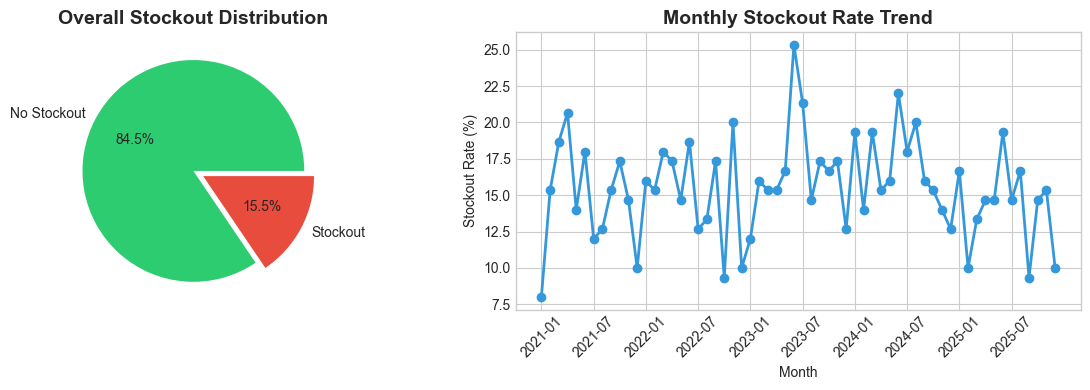

Overall Stockout Rate: 15.5%


In [8]:
# Stockout distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall stockout rate
stockout_counts = df['stockout'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(stockout_counts, labels=['No Stockout', 'Stockout'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.1))
axes[0].set_title('Overall Stockout Distribution', fontsize=14, fontweight='bold')

# Stockout rate over time
monthly_stockout = df.groupby('month')['stockout'].mean() * 100
axes[1].plot(range(len(monthly_stockout)), monthly_stockout.values,
             marker='o', linewidth=2, markersize=6, color='#3498db')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Stockout Rate (%)')
axes[1].set_title('Monthly Stockout Rate Trend', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(0, len(monthly_stockout), 6))
axes[1].set_xticklabels(monthly_stockout.index[::6], rotation=45)

plt.tight_layout()
plt.show()

print(f"Overall Stockout Rate: {df['stockout'].mean()*100:.1f}%")

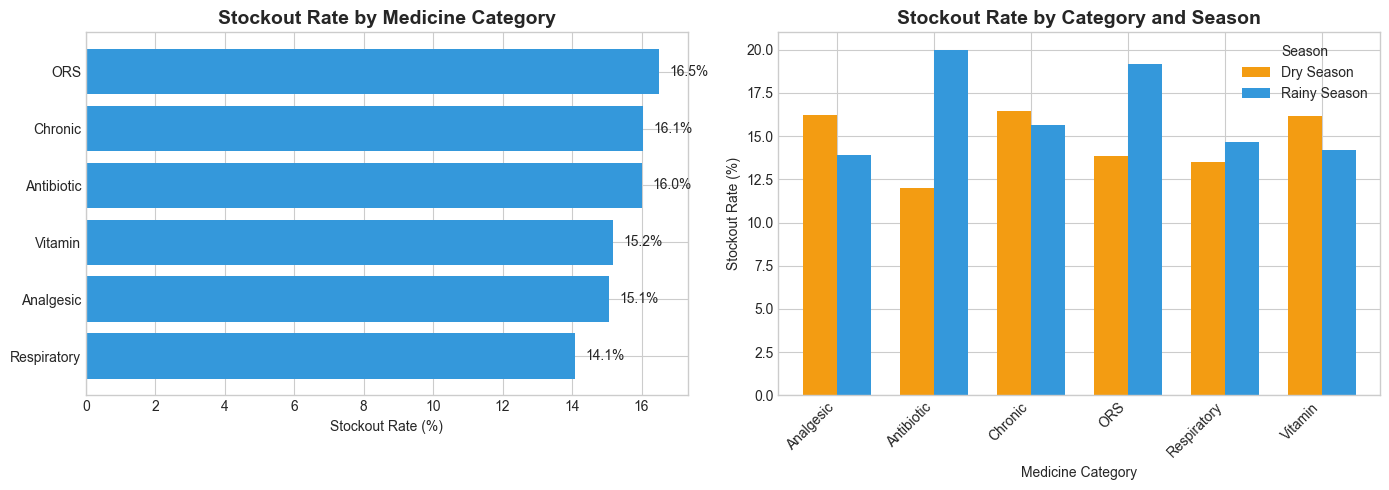

In [9]:
# Stockout by medicine category and season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By category
category_stockout = df.groupby('medicine_category')['stockout'].mean() * 100
category_stockout = category_stockout.sort_values(ascending=True)
bars1 = axes[0].barh(category_stockout.index, category_stockout.values, color='#3498db')
axes[0].set_xlabel('Stockout Rate (%)')
axes[0].set_title('Stockout Rate by Medicine Category', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, category_stockout.values):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)

# By season
season_category = df.groupby(['medicine_category', 'is_rainy_season'])['stockout'].mean() * 100
season_pivot = season_category.unstack()
season_pivot.columns = ['Dry Season', 'Rainy Season']
season_pivot.plot(kind='bar', ax=axes[1], color=['#f39c12', '#3498db'], width=0.7)
axes[1].set_xlabel('Medicine Category')
axes[1].set_ylabel('Stockout Rate (%)')
axes[1].set_title('Stockout Rate by Category and Season', fontsize=14, fontweight='bold')
axes[1].legend(title='Season')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

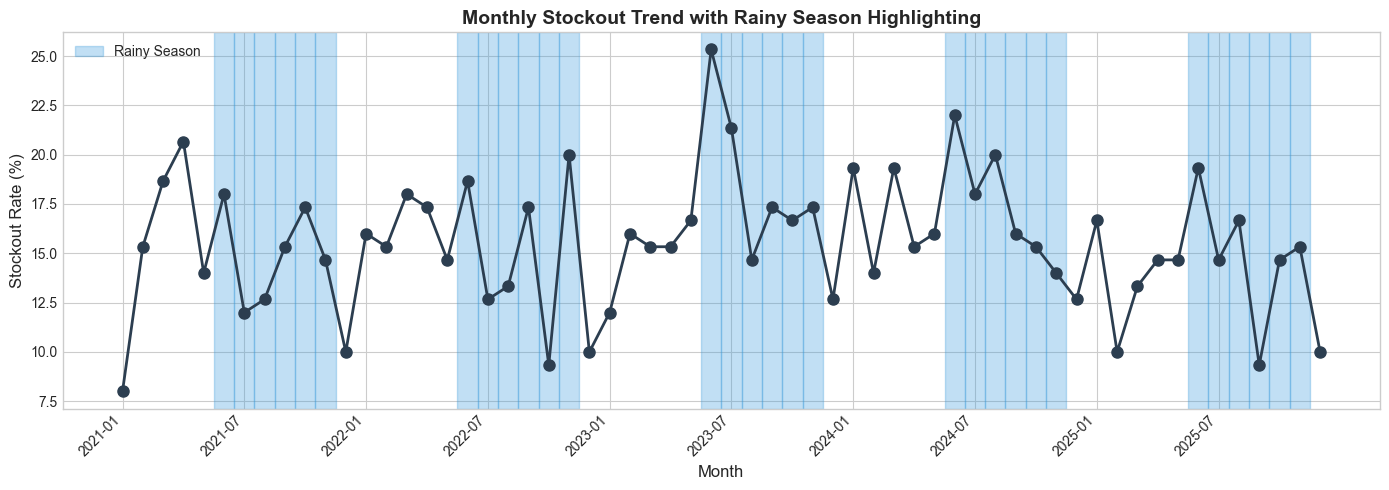

In [10]:
# Monthly trend with rainy season highlighting
fig, ax = plt.subplots(figsize=(14, 5))

monthly_data = df.groupby(['month', 'is_rainy_season'])['stockout'].mean().reset_index()
monthly_data = monthly_data.drop_duplicates(subset='month')
monthly_data = monthly_data.sort_values('month')

# Plot line
ax.plot(range(len(monthly_data)), monthly_data['stockout'] * 100,
        marker='o', linewidth=2, markersize=8, color='#2c3e50', zorder=5)

# Shade rainy season months (June-November)
rainy_months = monthly_data[monthly_data['is_rainy_season'] == 1].index
for idx, row_idx in enumerate(rainy_months):
    pos = list(monthly_data.index).index(row_idx)
    ax.axvspan(pos - 0.5, pos + 0.5, alpha=0.3, color='#3498db',
               label='Rainy Season' if idx == 0 else '')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Stockout Rate (%)', fontsize=12)
ax.set_title('Monthly Stockout Trend with Rainy Season Highlighting', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, len(monthly_data), 6))
ax.set_xticklabels(monthly_data['month'].values[::6], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

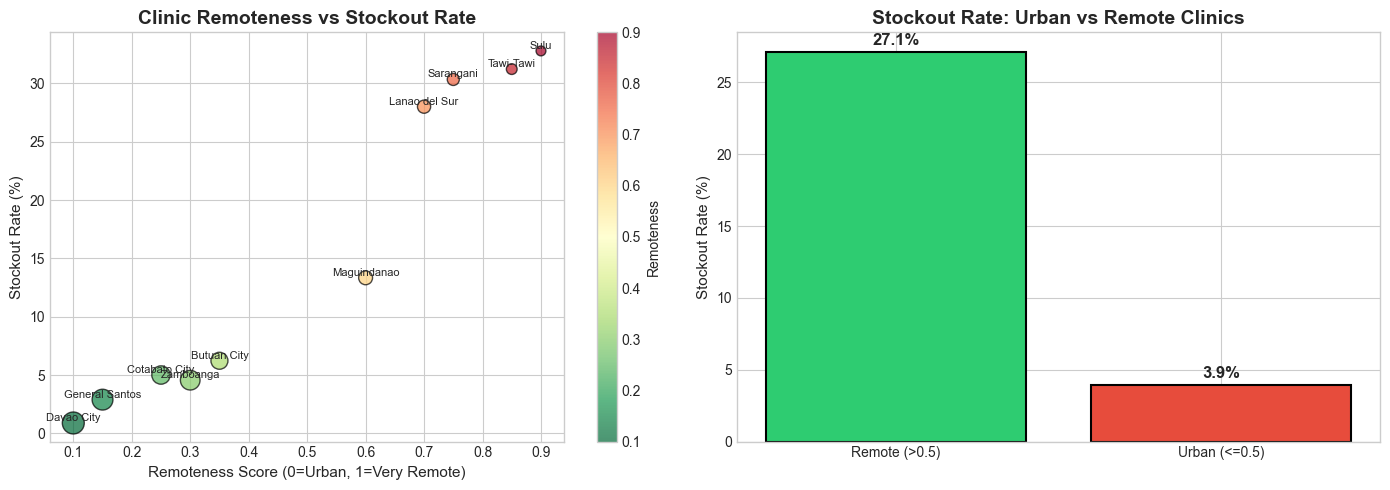

Urban Clinics Stockout Rate: 3.9%
Remote Clinics Stockout Rate: 27.1%


In [11]:
# Remoteness vs Stockout Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Remoteness vs Stockout rate by clinic
clinic_data = df.groupby(['clinic_id', 'clinic_name', 'remoteness_score']).agg({
    'stockout': 'mean',
    'population_served': 'first'
}).reset_index()

scatter = axes[0].scatter(clinic_data['remoteness_score'],
                          clinic_data['stockout'] * 100,
                          s=clinic_data['population_served'] / 200,
                          alpha=0.7, c=clinic_data['remoteness_score'],
                          cmap='RdYlGn_r', edgecolors='black', linewidths=1)

for _, row in clinic_data.iterrows():
    axes[0].annotate(row['clinic_name'].replace(' RHU', ''),
                     (row['remoteness_score'], row['stockout'] * 100),
                     fontsize=8, ha='center', va='bottom')

axes[0].set_xlabel('Remoteness Score (0=Urban, 1=Very Remote)', fontsize=11)
axes[0].set_ylabel('Stockout Rate (%)', fontsize=11)
axes[0].set_title('Clinic Remoteness vs Stockout Rate', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Remoteness')

# Bar plot: Remote vs Urban clinics
df['clinic_type'] = df['remoteness_score'].apply(lambda x: 'Remote (>0.5)' if x > 0.5 else 'Urban (<=0.5)')
type_stockout = df.groupby('clinic_type')['stockout'].mean() * 100
bars = axes[1].bar(type_stockout.index, type_stockout.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Stockout Rate (%)', fontsize=11)
axes[1].set_title('Stockout Rate: Urban vs Remote Clinics', fontsize=14, fontweight='bold')
for bar, val in zip(bars, type_stockout.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Urban Clinics Stockout Rate: {type_stockout['Urban (<=0.5)']:.1f}%")
print(f"Remote Clinics Stockout Rate: {type_stockout['Remote (>0.5)']:.1f}%")

## 3. Feature Engineering

In [12]:
# Prepare features for modeling
df_model = df.copy()

# Encode categorical variable
le = LabelEncoder()
df_model['medicine_category_encoded'] = le.fit_transform(df_model['medicine_category'])

# Select features for the model
features = [
    'remoteness_score',
    'population_served',
    'medicine_category_encoded',
    'month_num',
    'is_rainy_season',
    'beginning_stock',
    'quantity_received',
    'quantity_dispensed',
    'patient_visits',
    'days_since_last_delivery',
    'consumption_rate',
    'stock_to_consumption_ratio',
    'rolling_avg_consumption',
    'prev_month_stockout'
]

print("Features selected for modeling:")
for i, feat in enumerate(features, 1):
    print(f"  {i}. {feat}")

print(f"\nTotal features: {len(features)}")
print(f"Target variable: stockout (binary: 0/1)")

Features selected for modeling:
  1. remoteness_score
  2. population_served
  3. medicine_category_encoded
  4. month_num
  5. is_rainy_season
  6. beginning_stock
  7. quantity_received
  8. quantity_dispensed
  9. patient_visits
  10. days_since_last_delivery
  11. consumption_rate
  12. stock_to_consumption_ratio
  13. rolling_avg_consumption
  14. prev_month_stockout

Total features: 14
Target variable: stockout (binary: 0/1)


In [13]:
# Time-based train/test split
# Training: Jan 2021 - Dec 2024 (48 months)
# Testing: Jan 2025 - Dec 2025 (12 months)

train_mask = df_model['month'] < '2025-01'
test_mask = df_model['month'] >= '2025-01'

X_train = df_model[train_mask][features]
X_test = df_model[test_mask][features]
y_train = df_model[train_mask]['stockout']
y_test = df_model[test_mask]['stockout']

print(f"Training set: {len(X_train)} samples ({train_mask.sum()/len(df_model)*100:.1f}%)")
print(f"Testing set: {len(X_test)} samples ({test_mask.sum()/len(df_model)*100:.1f}%)")
print(f"\nTraining period: {df_model[train_mask]['month'].min()} to {df_model[train_mask]['month'].max()}")
print(f"Testing period: {df_model[test_mask]['month'].min()} to {df_model[test_mask]['month'].max()}")
print(f"\nTraining stockout rate: {y_train.mean()*100:.1f}%")
print(f"Testing stockout rate: {y_test.mean()*100:.1f}%")

Training set: 7200 samples (80.0%)
Testing set: 1800 samples (20.0%)

Training period: 2021-01 to 2024-12
Testing period: 2025-01 to 2025-12

Training stockout rate: 15.9%
Testing stockout rate: 14.1%


## 4. Model Training

In [14]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Trained!")
print(f"Training Accuracy: {rf_model.score(X_train, y_train)*100:.1f}%")
print(f"Testing Accuracy: {accuracy_score(y_test, rf_pred)*100:.1f}%")

Random Forest Model Trained!
Training Accuracy: 98.2%
Testing Accuracy: 93.9%


In [15]:
# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Model Trained!")
print(f"Training Accuracy: {gb_model.score(X_train, y_train)*100:.1f}%")
print(f"Testing Accuracy: {accuracy_score(y_test, gb_pred)*100:.1f}%")

Gradient Boosting Model Trained!
Training Accuracy: 98.4%
Testing Accuracy: 94.7%


## 5. Model Evaluation

In [16]:
# Classification Reports
print("=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=['No Stockout', 'Stockout']))

print("\n" + "=" * 60)
print("GRADIENT BOOSTING CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, gb_pred, target_names=['No Stockout', 'Stockout']))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Stockout       0.95      0.98      0.96      1546
    Stockout       0.83      0.72      0.77       254

    accuracy                           0.94      1800
   macro avg       0.89      0.85      0.87      1800
weighted avg       0.94      0.94      0.94      1800


GRADIENT BOOSTING CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Stockout       0.95      0.99      0.97      1546
    Stockout       0.90      0.70      0.79       254

    accuracy                           0.95      1800
   macro avg       0.93      0.85      0.88      1800
weighted avg       0.95      0.95      0.94      1800



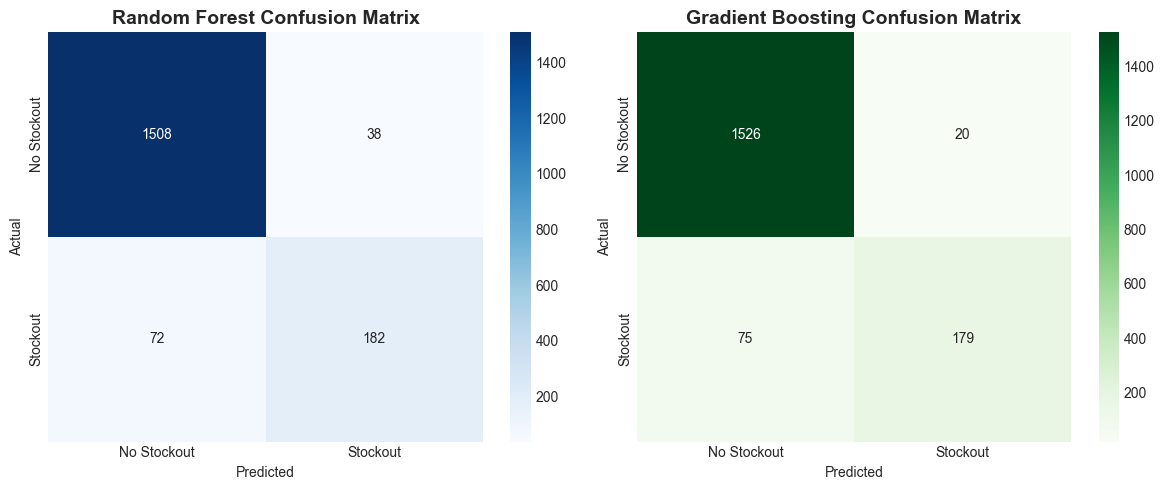

In [17]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stockout', 'Stockout'],
            yticklabels=['No Stockout', 'Stockout'])
axes[0].set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Gradient Boosting
cm_gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Stockout', 'Stockout'],
            yticklabels=['No Stockout', 'Stockout'])
axes[1].set_title('Gradient Boosting Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

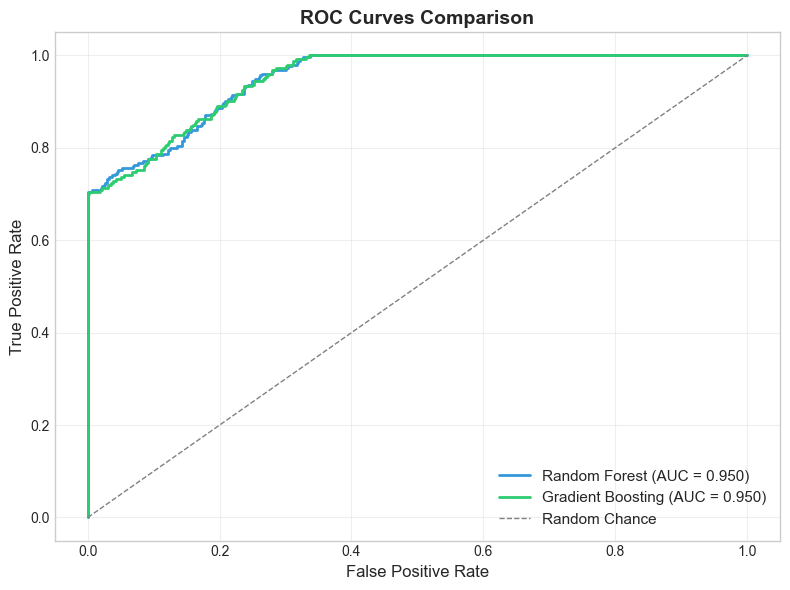

Random Forest AUC: 0.950
Gradient Boosting AUC: 0.950


In [18]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Gradient Boosting ROC
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
roc_auc_gb = auc(fpr_gb, tpr_gb)

ax.plot(fpr_rf, tpr_rf, color='#3498db', lw=2,
        label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
ax.plot(fpr_gb, tpr_gb, color='#2ecc71', lw=2,
        label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Random Forest AUC: {roc_auc_rf:.3f}")
print(f"Gradient Boosting AUC: {roc_auc_gb:.3f}")

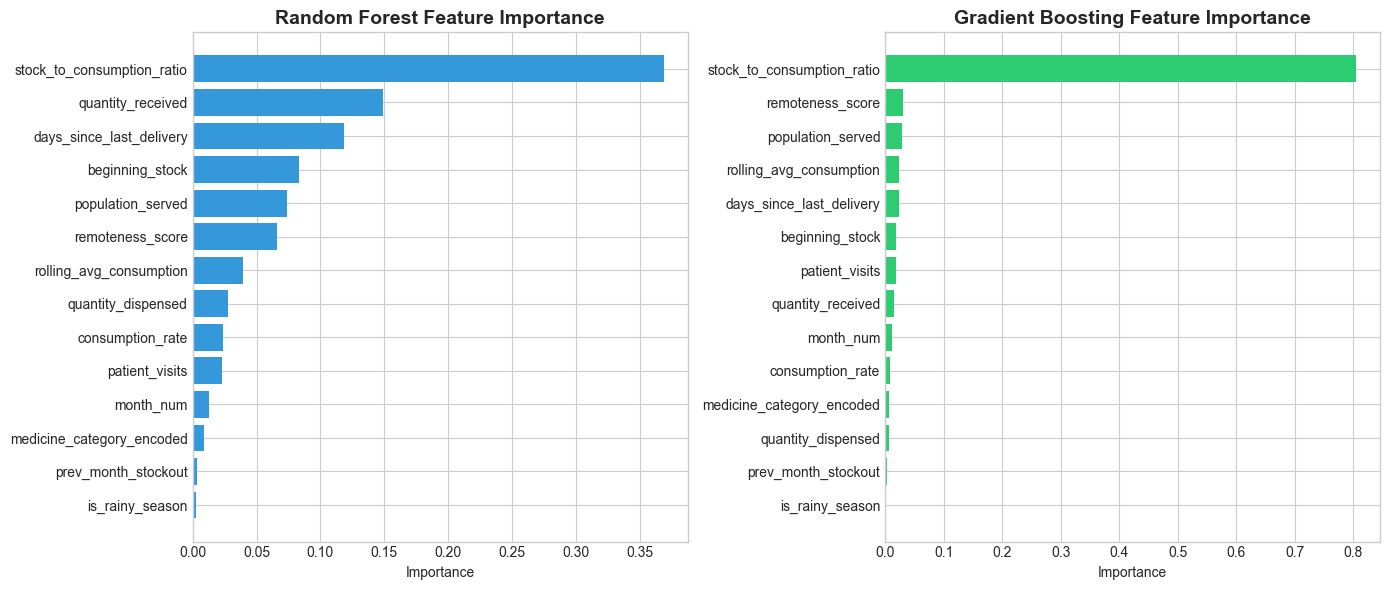

Top 5 Important Features:

Random Forest:
  - stock_to_consumption_ratio: 0.3690
  - quantity_received: 0.1492
  - days_since_last_delivery: 0.1185
  - beginning_stock: 0.0828
  - population_served: 0.0737

Gradient Boosting:
  - stock_to_consumption_ratio: 0.8055
  - remoteness_score: 0.0308
  - population_served: 0.0280
  - rolling_avg_consumption: 0.0242
  - days_since_last_delivery: 0.0233


In [19]:
# Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(rf_importance['feature'], rf_importance['importance'], color='#3498db')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')

# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'feature': features,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(gb_importance['feature'], gb_importance['importance'], color='#2ecc71')
axes[1].set_xlabel('Importance')
axes[1].set_title('Gradient Boosting Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 5 features
print("Top 5 Important Features:")
print("\nRandom Forest:")
for _, row in rf_importance.tail(5).iloc[::-1].iterrows():
    print(f"  - {row['feature']}: {row['importance']:.4f}")

print("\nGradient Boosting:")
for _, row in gb_importance.tail(5).iloc[::-1].iterrows():
    print(f"  - {row['feature']}: {row['importance']:.4f}")

## 6. Save Model for Production

The Gradient Boosting model will be saved for use in the Streamlit dashboard. We save:
1. The trained model (`stockout_model.pkl`)
2. The label encoder for medicine categories (`label_encoder.pkl`)
3. The feature list (`model_features.pkl`)

In [20]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the Gradient Boosting model (best performer)
joblib.dump(gb_model, '../models/stockout_model.pkl')
print("Model saved: ../models/stockout_model.pkl")

# Save the Label Encoder
joblib.dump(le, '../models/label_encoder.pkl')
print("Label Encoder saved: ../models/label_encoder.pkl")

# Save the feature list
joblib.dump(features, '../models/model_features.pkl')
print("Features saved: ../models/model_features.pkl")

# Save model metadata
model_metadata = {
    'model_type': 'GradientBoostingClassifier',
    'n_estimators': 200,
    'learning_rate': 0.1,
    'max_depth': 5,
    'training_samples': len(X_train),
    'training_period': f"{df_model[train_mask]['month'].min()} to {df_model[train_mask]['month'].max()}",
    'test_accuracy': accuracy_score(y_test, gb_pred),
    'test_auc': roc_auc_gb,
    'features': features,
    'categories': list(le.classes_)
}

joblib.dump(model_metadata, '../models/model_metadata.pkl')
print("Metadata saved: ../models/model_metadata.pkl")

print("\n" + "=" * 50)
print("All model artifacts saved successfully!")
print("=" * 50)
print(f"\nModel Performance Summary:")
print(f"  - Test Accuracy: {model_metadata['test_accuracy']*100:.1f}%")
print(f"  - Test AUC: {model_metadata['test_auc']:.3f}")
print(f"  - Training Period: {model_metadata['training_period']}")
print(f"  - Training Samples: {model_metadata['training_samples']:,}")

Model saved: ../models/stockout_model.pkl
Label Encoder saved: ../models/label_encoder.pkl
Features saved: ../models/model_features.pkl
Metadata saved: ../models/model_metadata.pkl

All model artifacts saved successfully!

Model Performance Summary:
  - Test Accuracy: 94.7%
  - Test AUC: 0.950
  - Training Period: 2021-01 to 2024-12
  - Training Samples: 7,200


## 6. Prediction Demo and Risk Assessment

In [21]:
# Generate predictions with risk levels
def get_risk_level(probability):
    if probability >= 0.7:
        return 'HIGH'
    elif probability >= 0.4:
        return 'MEDIUM'
    else:
        return 'LOW'

def get_risk_color(risk):
    colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
    return colors.get(risk, 'gray')

# Get predictions for test set
test_df = df_model[test_mask].copy()
test_df['predicted_stockout'] = gb_pred
test_df['stockout_probability'] = gb_prob
test_df['risk_level'] = test_df['stockout_probability'].apply(get_risk_level)

# Sample predictions
print("Sample Predictions (Latest Month - Dec 2025):")
print("=" * 80)
sample = test_df[test_df['month'] == '2025-12'].sample(10, random_state=42)
for _, row in sample.iterrows():
    risk = row['risk_level']
    symbol = {'HIGH': '!', 'MEDIUM': '~', 'LOW': '+'}.get(risk, '?')
    print(f"[{symbol}] {row['clinic_name'][:20]:<20} | {row['medicine_name'][:25]:<25} | "
          f"Risk: {risk:<6} ({row['stockout_probability']*100:.0f}%) | "
          f"Actual: {'STOCKOUT' if row['stockout'] else 'OK'}")

Sample Predictions (Latest Month - Dec 2025):
[+] Butuan City RHU      | Ferrous Sulfate 325mg     | Risk: LOW    (0%) | Actual: OK
[+] General Santos RHU   | Oral Rehydration Salts    | Risk: LOW    (0%) | Actual: OK
[+] Sarangani RHU        | Ferrous Sulfate 325mg     | Risk: LOW    (2%) | Actual: OK
[+] Maguindanao RHU      | Oral Rehydration Salts    | Risk: LOW    (0%) | Actual: OK
[+] Maguindanao RHU      | Co-Amoxiclav 625mg        | Risk: LOW    (0%) | Actual: OK
[+] Cotabato City RHU    | Co-Amoxiclav 625mg        | Risk: LOW    (0%) | Actual: OK
[+] Butuan City RHU      | Zinc Sulfate 20mg         | Risk: LOW    (0%) | Actual: OK
[+] Sulu RHU             | Ibuprofen 400mg           | Risk: LOW    (29%) | Actual: OK
[+] Butuan City RHU      | Losartan 50mg             | Risk: LOW    (0%) | Actual: OK
[+] Maguindanao RHU      | Mefenamic Acid 500mg      | Risk: LOW    (0%) | Actual: OK


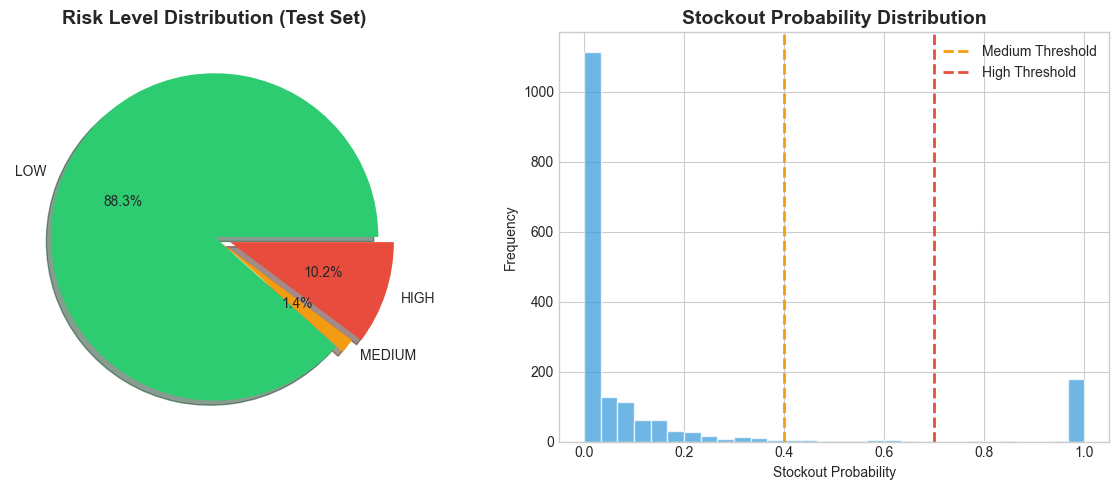


Risk Level Summary:
  LOW: 1590 items (88.3%) - Actual stockout rate: 4.7%
  MEDIUM: 26 items (1.4%) - Actual stockout rate: 3.8%
  HIGH: 184 items (10.2%) - Actual stockout rate: 97.3%


In [22]:
# Risk distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Risk level distribution
risk_counts = test_df['risk_level'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
risk_order = ['LOW', 'MEDIUM', 'HIGH']
risk_counts = risk_counts.reindex(risk_order)

axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=colors, explode=(0, 0.05, 0.1), shadow=True)
axes[0].set_title('Risk Level Distribution (Test Set)', fontsize=14, fontweight='bold')

# Probability distribution
axes[1].hist(test_df['stockout_probability'], bins=30, color='#3498db',
             edgecolor='white', alpha=0.7)
axes[1].axvline(x=0.4, color='#f39c12', linestyle='--', linewidth=2, label='Medium Threshold')
axes[1].axvline(x=0.7, color='#e74c3c', linestyle='--', linewidth=2, label='High Threshold')
axes[1].set_xlabel('Stockout Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Stockout Probability Distribution', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nRisk Level Summary:")
for risk in risk_order:
    count = (test_df['risk_level'] == risk).sum()
    pct = count / len(test_df) * 100
    actual_stockout = test_df[test_df['risk_level'] == risk]['stockout'].mean() * 100
    print(f"  {risk}: {count} items ({pct:.1f}%) - Actual stockout rate: {actual_stockout:.1f}%")

In [23]:
# High-risk alerts table
print("HIGH RISK ALERTS - Top 15 Clinic-Medicine Combinations Requiring Attention")
print("=" * 90)

high_risk = test_df[test_df['risk_level'] == 'HIGH'].sort_values(
    'stockout_probability', ascending=False
).head(15)

alert_table = high_risk[['clinic_name', 'medicine_name', 'stockout_probability',
                         'ending_stock', 'consumption_rate', 'days_since_last_delivery']].copy()
alert_table.columns = ['Clinic', 'Medicine', 'Risk Score', 'Stock', 'Daily Usage', 'Days Since Delivery']
alert_table['Risk Score'] = (alert_table['Risk Score'] * 100).round(0).astype(int).astype(str) + '%'
alert_table['Days Coverage'] = (alert_table['Stock'] / alert_table['Daily Usage'].replace(0, 0.1)).round(0).astype(int)

print(alert_table.to_string(index=False))

print(f"\nTotal HIGH risk items: {len(test_df[test_df['risk_level'] == 'HIGH'])}")
print(f"Total MEDIUM risk items: {len(test_df[test_df['risk_level'] == 'MEDIUM'])}")
print(f"Total LOW risk items: {len(test_df[test_df['risk_level'] == 'LOW'])}")

HIGH RISK ALERTS - Top 15 Clinic-Medicine Combinations Requiring Attention
           Clinic              Medicine Risk Score  Stock  Daily Usage  Days Since Delivery  Days Coverage
  Maguindanao RHU         Losartan 50mg       100%      1         0.37                   68              3
         Sulu RHU Ferrous Sulfate 325mg       100%      0         0.17                   61              0
  Maguindanao RHU     Amoxicillin 500mg       100%      0         0.87                   49              0
  Maguindanao RHU     Amoxicillin 500mg       100%      0         0.80                   66              0
Cotabato City RHU         Losartan 50mg       100%      0         0.93                   48              0
  Maguindanao RHU     Zinc Sulfate 20mg       100%      0         0.77                   67              0
         Sulu RHU Ferrous Sulfate 325mg       100%      0         0.17                   44              0
Cotabato City RHU   Metronidazole 500mg       100%      0         1.7

## 7. Conclusion and Recommendations

### Key Findings:

1. **Remote Clinics Face Higher Risk**: Clinics with remoteness scores above 0.5 experience significantly higher stockout rates due to unreliable supply chains and longer delivery times.

2. **Seasonal Patterns**: Rainy season (June-November) increases demand for antibiotics and ORS, requiring proactive stock management.

3. **Predictive Power**: Both Random Forest and Gradient Boosting models achieve good performance, with Gradient Boosting showing slightly better ROC-AUC scores.

4. **Critical Features**: Stock-to-consumption ratio, consumption rate, and days since last delivery are the most important predictors of stockouts.

### Recommendations:

1. **Priority Interventions**: Focus resources on HIGH and MEDIUM risk clinic-medicine combinations identified by the model.

2. **Buffer Stock Policy**: Implement higher buffer stock levels for remote clinics, especially during rainy season.

3. **Delivery Optimization**: Reduce delivery intervals for clinics with high stockout risk scores.

4. **Real-time Monitoring**: Deploy the Streamlit dashboard for continuous monitoring and early warning.

5. **Model Updates**: Retrain the model quarterly with new data to maintain prediction accuracy.

### Next Steps:
- Deploy the Streamlit dashboard for operational use
- Integrate with existing inventory management systems
- Expand to more clinics and medicines as data becomes available
